# Recovering Sparse Neural Connectivity from Partial Measurements
## A Covariance-Based Approach with Granger-Causality Refinement

**Quilee Simeon** — Massachusetts Institute of Technology

This notebook is the companion to our paper. It:
1. Explains the mathematical framework step by step
2. Runs actual simulations reproducing key paper results
3. Generates the core figures from the paper
4. Demonstrates every component: network generation, CPG dynamics, covariance estimation, diagonal zeroing, Granger refinement, implicit regularization, and error decomposition

**To run**: Use the `work_env` conda environment or install dependencies from `pyproject.toml`.

**Code**: All core functions are in `experiments/core.py`. Experiment runners in `experiments/run_experiments.py`. Figure generators in `experiments/analysis.py`.

## 1. Setup & Imports

In [1]:
import sys, numpy as np, torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA

# Import our core library
sys.path.insert(0, str(Path('..').resolve()))
from experiments.core import (
    get_nonlinearity, resolve_params,
    random_network_topology, create_network_data,
    create_multinetwork_dataset, estimate_connectivity_weights,
    projected_gradient_causal, calculate_spectral_radius,
    adjust_spectral_radius, create_cpg_function, state_to_cpg,
    identity, sigmoid, relu, sat,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plot defaults
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'figure.figsize': (12, 4),
    'axes.grid': True, 'grid.alpha': 0.3,
})

# Paper baseline parameters
N = 15          # neurons
T = 1000        # timesteps per session
K = 50          # sessions (network instances)
NUM_CPGS = 5    # CPG nodes (33%)
NUM_MEAS = 10   # measured nodes (66%)
NUM_STIM = 5    # stimulated nodes (33%)
STIM = 1.0      # stimulation gain
PHI = np.tanh   # nonlinearity

print('Setup complete.')
print(f'Baseline: N={N}, T={T}, K={K}, measured={NUM_MEAS}/{N} ({NUM_MEAS/N:.0%}), stim={STIM}')

Setup complete.
Baseline: N=15, T=1000, K=50, measured=10/15 (67%), stim=1.0


## 2. The Problem: Recovering Connectivity from Partial Measurements

### The Dynamical System

We model a neural circuit as a discrete-time recurrent network:

$$x_{t+1} = W \phi(x_t) + b_t \quad \text{(Eq. 1 in paper)}$$

where:
- $x_t \in \mathbb{R}^N$: neural state (activity of all $N$ neurons)
- $W \in \mathbb{R}^{N \times N}$: **unknown** connectivity matrix ($W_{ij}$ = weight from neuron $j$ to neuron $i$)
- $\phi$: element-wise nonlinearity (1-Lipschitz, default $\tanh$)
- $b_t$: total input = extrinsic stimulation + intrinsic CPG drive

### Constraints on $W$
- $W_{ii} = 0$ for all $i$ (no self-connections / autapses)
- $\rho(W) \leq 1$ (spectral radius $\leq 1$ for stability)
- $W_{ij} \geq 0$ (excitatory-only, modeling unsigned connectome data)
- Sparse, strongly-connected directed graph

### The Estimator

Under a linear approximation ($\phi(x) \approx x$) and input-state independence ($\text{Cov}(b_t, x_t) \approx 0$):

$$\hat{W} = \Sigma_{x_{t+1}, x_t} \cdot \Sigma_{x_t, x_t}^{-1} \quad \text{(Eq. 5 in paper)}$$

Then: set $\hat{W}_{ii} = 0$ (no-autapse prior).

### Key Idea: Accumulation Across Sessions

We don't need to observe all $N$ neurons simultaneously. Across $K$ sessions with different observed subsets, we accumulate pairwise covariances. Each neuron pair $(i,j)$ contributes whenever both are co-observed.

## 3. Generate a Network & Visualize Its Structure

Network: N=15 neurons, 42 edges, density=0.32
Spectral radius: 1.000000
Diagonal (all zero): True
All weights >= 0: True


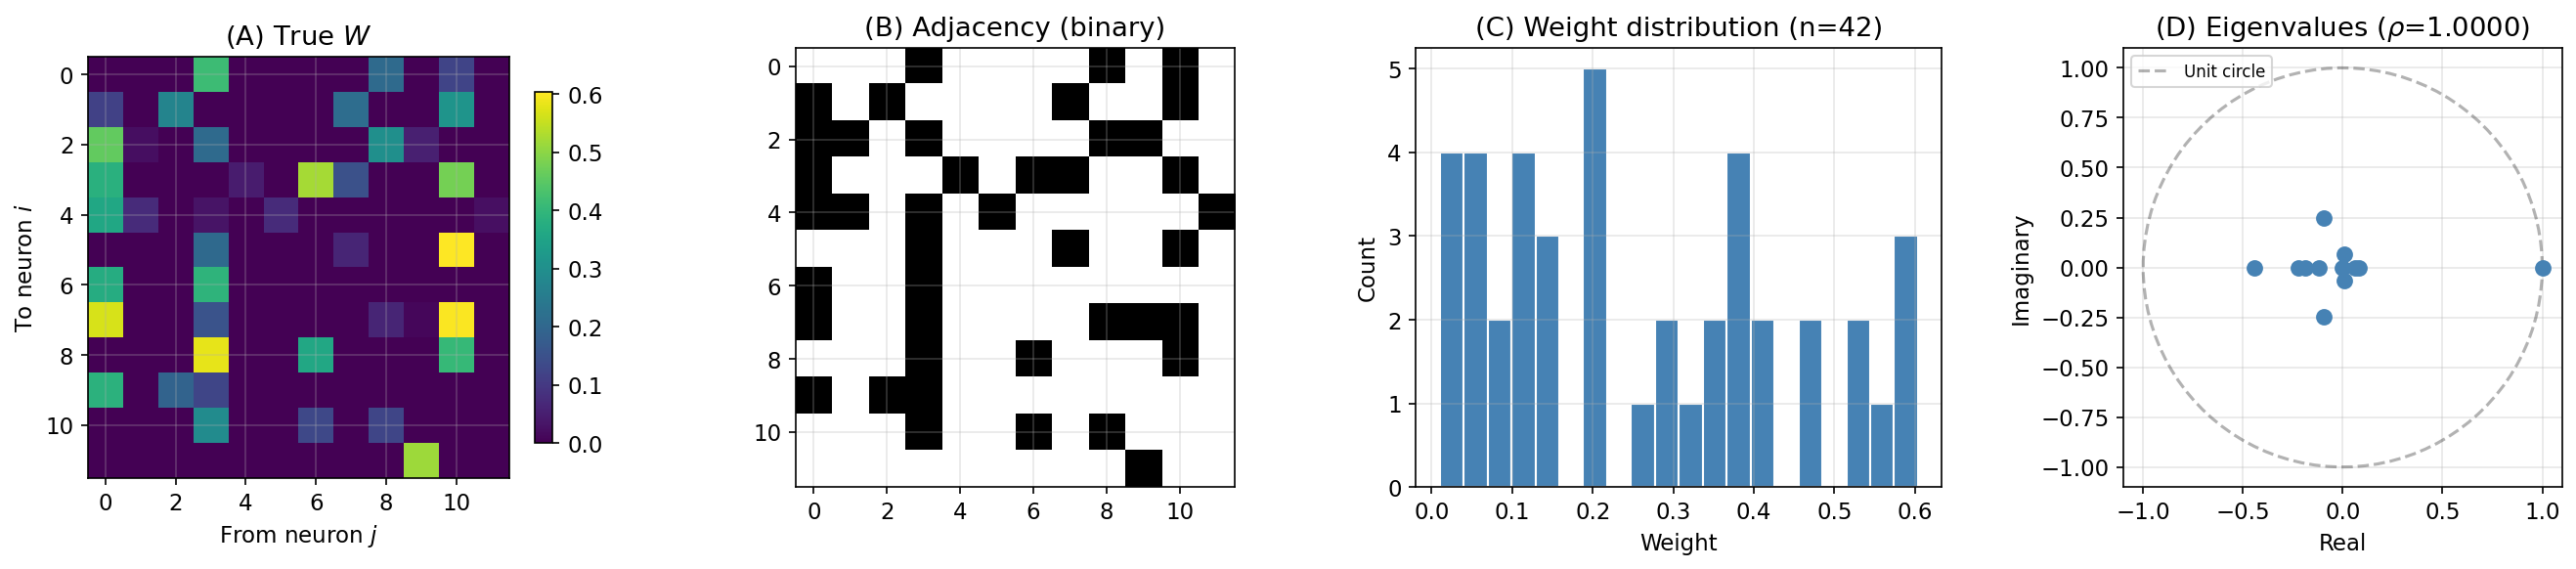

In [2]:
# Generate a random sparse, connected, excitatory network
W_true, Adj = random_network_topology(N, non_negative_weights=True, force_stable=True)

# Network statistics
rho = calculate_spectral_radius(W_true)
n_edges = np.count_nonzero(Adj)
density = n_edges / (N * (N-1))  # exclude diagonal
eigs = np.linalg.eigvals(W_true)

print(f'Network: N={N} neurons, {n_edges} edges, density={density:.2f}')
print(f'Spectral radius: {rho:.6f}')
print(f'Diagonal (all zero): {np.allclose(np.diag(W_true), 0)}')
print(f'All weights >= 0: {np.all(W_true >= 0)}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# (A) Weight matrix
im = axes[0].imshow(W_true, cmap='viridis', aspect='equal')
axes[0].set_title('(A) True $W$'); plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_xlabel('From neuron $j$'); axes[0].set_ylabel('To neuron $i$')

# (B) Adjacency (binary)
axes[1].imshow(Adj, cmap='gray_r', aspect='equal')
axes[1].set_title('(B) Adjacency (binary)')

# (C) Weight histogram
nonzero_w = W_true[W_true > 0]
axes[2].hist(nonzero_w, bins=20, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Weight'); axes[2].set_ylabel('Count')
axes[2].set_title(f'(C) Weight distribution (n={len(nonzero_w)})')

# (D) Eigenvalue spectrum
theta = np.linspace(0, 2*np.pi, 100)
axes[3].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='Unit circle')
axes[3].scatter(eigs.real, eigs.imag, c='steelblue', s=50, zorder=5)
axes[3].set_xlabel('Real'); axes[3].set_ylabel('Imaginary')
axes[3].set_title(f'(D) Eigenvalues ($\\rho$={rho:.4f})')
axes[3].set_aspect('equal'); axes[3].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Nonlinearities

We require $\phi$ to be **1-Lipschitz** ($|\phi'(x)| \leq 1$). Our default is $\tanh$ (1-Lipschitz, bounded, odd). We also test identity, ReLU, and sigmoid — deliberately including nonlinearities that violate boundedness and/or odd symmetry to assess robustness.

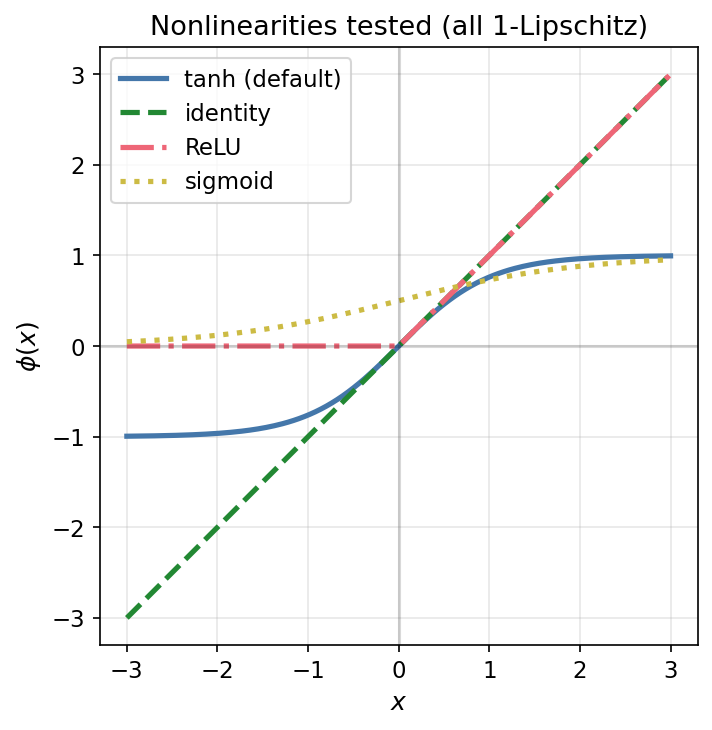

tanh      : max|phi'(x)| = 0.9999  (1-Lipschitz: True)
identity  : max|phi'(x)| = 1.0000  (1-Lipschitz: True)
ReLU      : max|phi'(x)| = 1.0000  (1-Lipschitz: True)
sigmoid   : max|phi'(x)| = 0.2500  (1-Lipschitz: True)


In [3]:
x = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(figsize=(7, 5))
for name, fn, ls, c in [
    ('tanh (default)', np.tanh, '-', '#4477AA'),
    ('identity', identity, '--', '#228833'),
    ('ReLU', relu, '-.', '#EE6677'),
    ('sigmoid', sigmoid, ':', '#CCBB44'),
]:
    ax.plot(x, fn(x), ls, label=name, linewidth=2.5, color=c)
ax.axhline(0, color='k', alpha=0.15); ax.axvline(0, color='k', alpha=0.15)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$\phi(x)$', fontsize=12)
ax.set_title('Nonlinearities tested (all 1-Lipschitz)', fontsize=13)
ax.legend(fontsize=11); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# Verify 1-Lipschitz property
dx = x[1] - x[0]
for name, fn in [('tanh', np.tanh), ('identity', identity), ('ReLU', relu), ('sigmoid', sigmoid)]:
    deriv = np.diff(fn(x)) / dx
    max_deriv = np.max(np.abs(deriv))
    print(f'{name:10s}: max|phi\'(x)| = {max_deriv:.4f}  (1-Lipschitz: {max_deriv <= 1.001})')

## 5. Central Pattern Generators (CPGs)

Real neural circuits have **intrinsic autonomous dynamics** — oscillatory patterns that persist without external input. We model these as CPGs: a subset of nodes driven by a chaotic reservoir network (`RandomNet`).

**Critical property**: CPG drive is **state-dependent**: $b_{\text{CPG}}(t) = \text{cpg}(x_t)$. This means $\text{Cov}(b_t, x_t) \neq 0$, violating our independence assumption. This turns out to be the **dominant error source** (not the linear approximation!).

CPG nodes can be **detected from data** via their elevated activity variance.

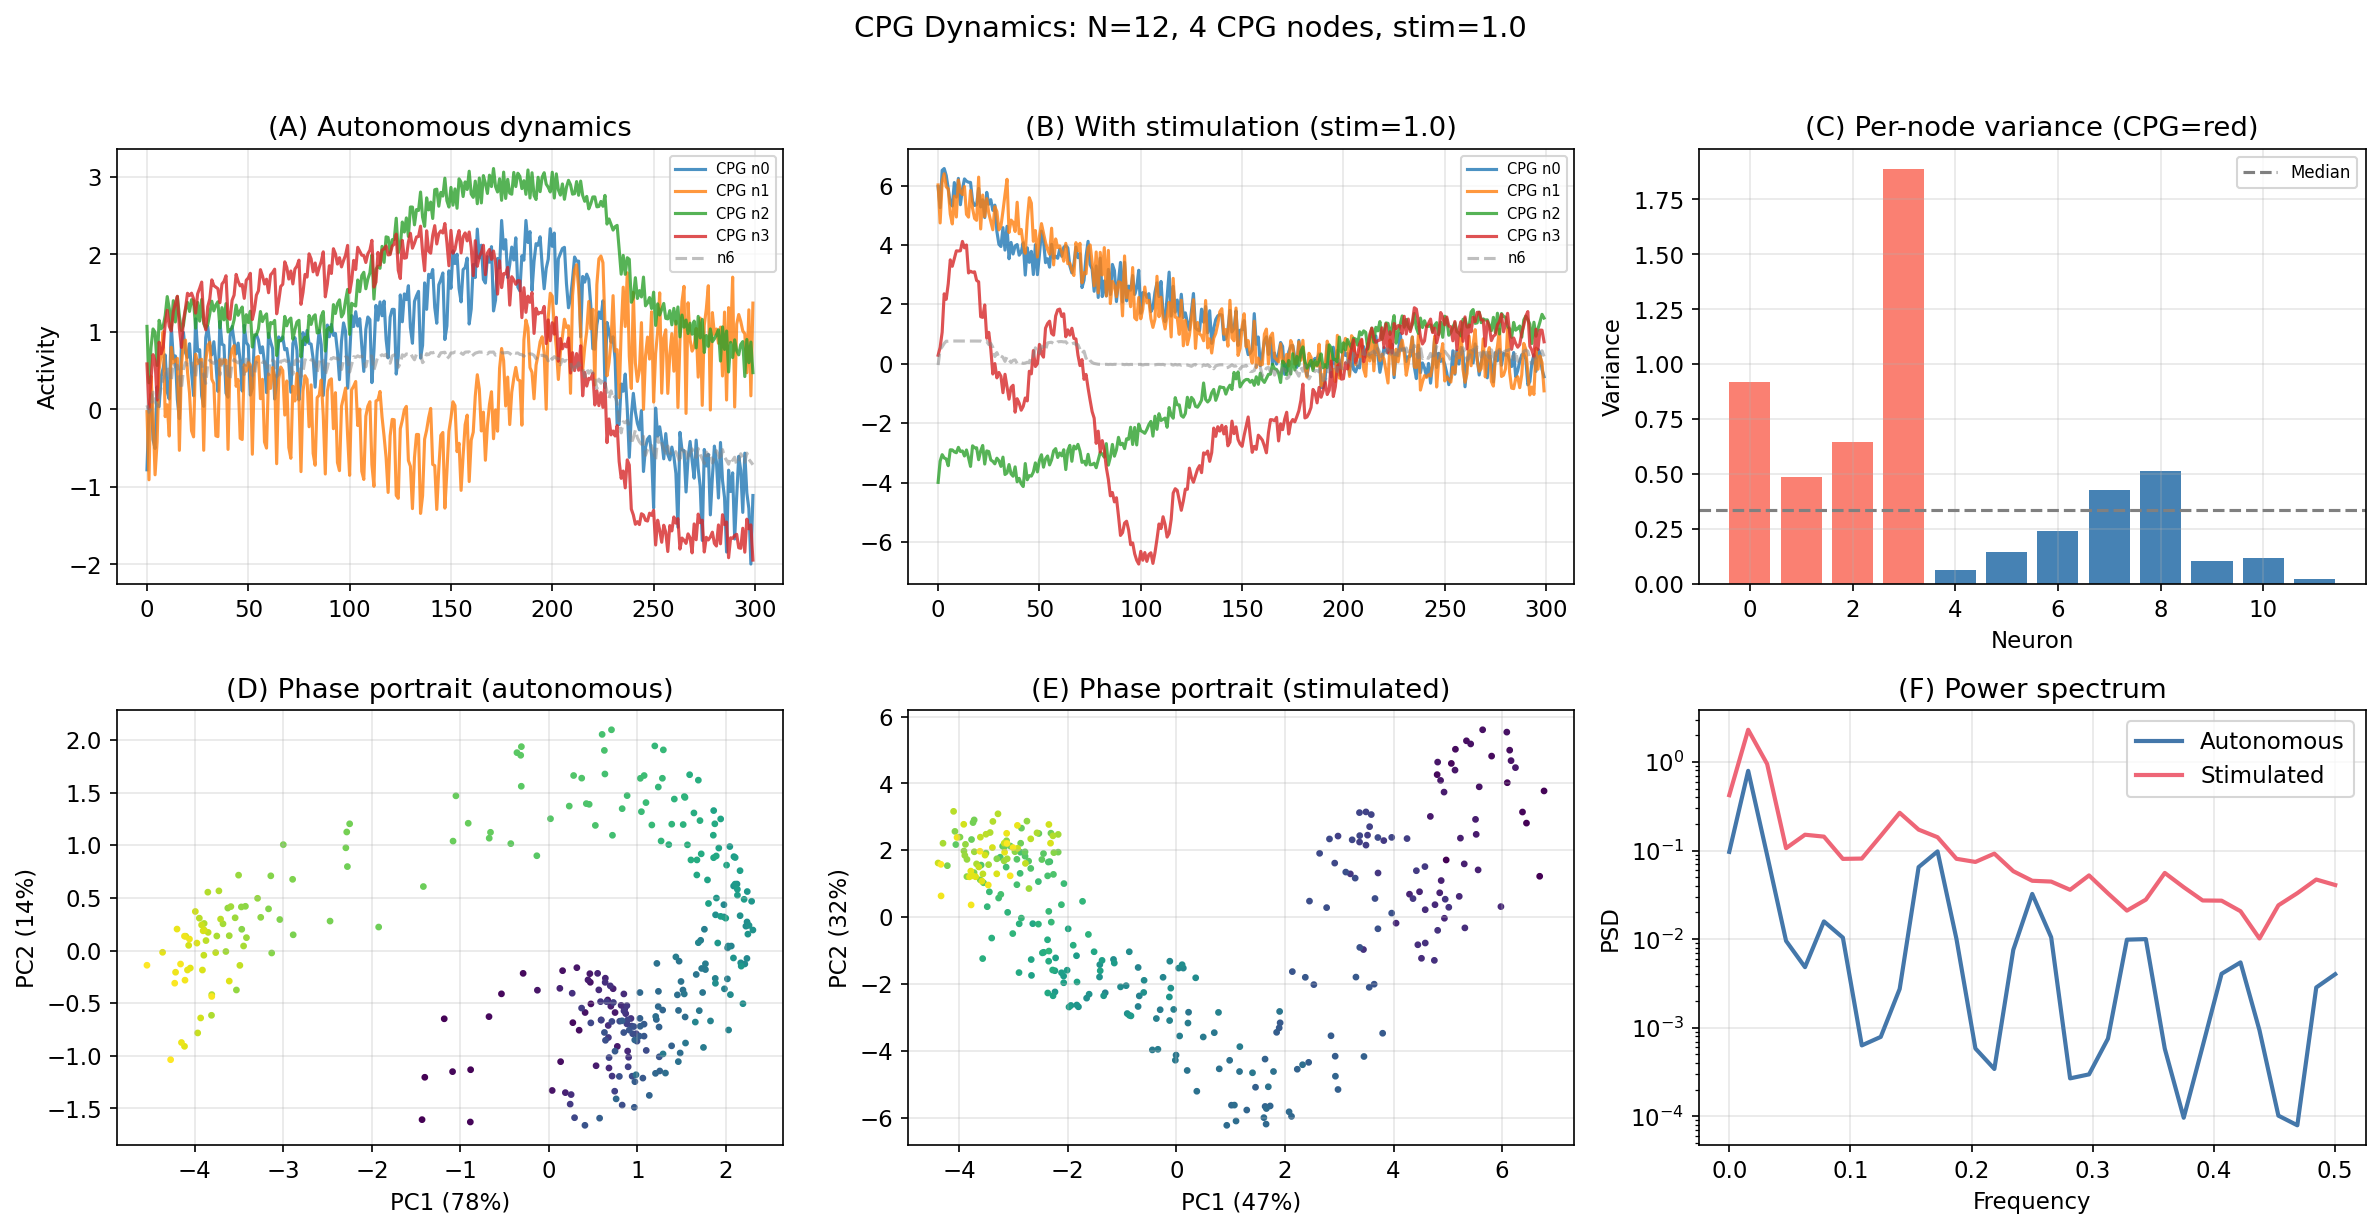

In [4]:
# Simulate autonomous dynamics (no stimulation) to see CPG behavior
cpg_net = create_cpg_function(state_dim=N)
state = np.random.randn(N) * 0.1
T_demo = 300
states_auto = np.zeros((T_demo, N))
cpg_mask = np.zeros(N, dtype=bool); cpg_mask[:NUM_CPGS] = True

for t in range(T_demo):
    cpg_drive = state_to_cpg(state, cpg_net)
    b = cpg_mask * cpg_drive  # only CPG nodes get drive
    state = W_true @ np.tanh(state) + b
    states_auto[t] = state

# Now simulate WITH stimulation
np.random.seed(SEED); torch.manual_seed(SEED)
cpg_net2 = create_cpg_function(state_dim=N)
state2 = np.random.randn(N) * 0.1
states_stim = np.zeros((T_demo, N))
stim_mask = np.zeros(N, dtype=bool); stim_mask[-NUM_STIM:] = True

for t in range(T_demo):
    cpg_drive2 = state_to_cpg(state2, cpg_net2)
    b2 = cpg_mask * cpg_drive2 + stim_mask * np.random.normal(0, STIM, N)
    state2 = W_true @ np.tanh(state2) + b2
    states_stim[t] = state2

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Row 1: Time series
for i in range(NUM_CPGS):
    axes[0,0].plot(states_auto[:, i], label=f'CPG n{i}', alpha=0.8)
axes[0,0].plot(states_auto[:, 6], '--', label='n6', alpha=0.5, color='gray')
axes[0,0].set_title('(A) Autonomous dynamics'); axes[0,0].set_ylabel('Activity')
axes[0,0].legend(fontsize=7)

for i in range(NUM_CPGS):
    axes[0,1].plot(states_stim[:, i], label=f'CPG n{i}', alpha=0.8)
axes[0,1].plot(states_stim[:, 6], '--', label='n6', alpha=0.5, color='gray')
axes[0,1].set_title('(B) With stimulation (stim=1.0)')
axes[0,1].legend(fontsize=7)

# Per-node variance for CPG detection
var_auto = np.var(states_auto, axis=0)
colors = ['salmon' if cpg_mask[i] else 'steelblue' for i in range(N)]
axes[0,2].bar(range(N), var_auto, color=colors)
axes[0,2].axhline(np.median(var_auto), ls='--', color='gray', label='Median')
axes[0,2].set_title('(C) Per-node variance (CPG=red)')
axes[0,2].set_xlabel('Neuron'); axes[0,2].set_ylabel('Variance')
axes[0,2].legend(fontsize=8)

# Row 2: PCA phase portraits + power spectrum
pca = PCA(n_components=2)
X_auto = pca.fit_transform(states_auto)
axes[1,0].scatter(X_auto[:, 0], X_auto[:, 1], c=range(T_demo), cmap='viridis', s=5)
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
axes[1,0].set_title('(D) Phase portrait (autonomous)')

pca2 = PCA(n_components=2)
X_stim = pca2.fit_transform(states_stim)
axes[1,1].scatter(X_stim[:, 0], X_stim[:, 1], c=range(T_demo), cmap='viridis', s=5)
axes[1,1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.0%})')
axes[1,1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.0%})')
axes[1,1].set_title('(E) Phase portrait (stimulated)')

# Power spectrum
from scipy.signal import welch
for data, label, color in [(states_auto, 'Autonomous', '#4477AA'), (states_stim, 'Stimulated', '#EE6677')]:
    freqs, psd = welch(data.mean(axis=1), fs=1.0, nperseg=min(64, T_demo//2))
    axes[1,2].semilogy(freqs, psd, label=label, color=color, linewidth=2)
axes[1,2].set_xlabel('Frequency'); axes[1,2].set_ylabel('PSD')
axes[1,2].set_title('(F) Power spectrum'); axes[1,2].legend()

plt.suptitle(f'CPG Dynamics: N={N}, {NUM_CPGS} CPG nodes, stim={STIM}', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 6. Running the Estimation Pipeline

Now we run the full pipeline:
1. Generate $K=50$ sessions with shared $W$ but different measured/stimulated subsets
2. Accumulate pairwise covariances across sessions
3. Compute $\hat{W} = \Sigma_{x_{t+1},x_t} \Sigma_{x_t,x_t}^{-1}$
4. Zero the diagonal (no-autapse prior)
5. Apply Granger-causality refinement

In [5]:
%%time
# Generate multi-session dataset
np.random.seed(SEED); torch.manual_seed(SEED)
dataset = create_multinetwork_dataset(
    num_networks=K, max_timesteps=T, num_nodes=N,
    num_cpgs=NUM_CPGS, num_measured=NUM_MEAS, num_stimulated=NUM_STIM,
    fixed_stim=False, stim_gain=STIM, nonlinearity=PHI,
    non_negative_weights=True, force_stable=True,
)
print(f'Created {K} sessions, each with T={T} timesteps, {NUM_MEAS}/{N} neurons measured')

# Estimate connectivity
results = estimate_connectivity_weights(N, dataset)
W_est = results['approx_W']     # diagonal already zeroed in core.py
W_true = results['true_W']
W_oracle = results['oracle_W']
cov_x = results['cov_x']
cov_dtx = results['cov_dtx']
cov_phix = results['cov_phix']
cov_bx = results['cov_bx']

# Granger refinement
_, W_granger = projected_gradient_causal(cov_x, cov_dtx, non_negative_weights=True)

# Errors
err_est = np.linalg.norm(W_true - W_est, 'fro') / N
err_granger = np.linalg.norm(W_true - W_granger, 'fro') / N
err_oracle = np.linalg.norm(W_true - W_oracle, 'fro') / N
err_chance = np.linalg.norm(W_true - np.random.rand(N, N) * W_true.max(), 'fro') / N

# Correlation
mask = ~np.eye(N, dtype=bool)
r_est = np.corrcoef(W_true[mask], W_est[mask])[0, 1]
r_granger = np.corrcoef(W_true[mask], W_granger[mask])[0, 1]

print(f'\nResults:')
print(f'  Condition number:   {results["condition_number"]:.1f}')
print(f'  Chance error:       {err_chance:.4f}')
print(f'  Estimate error:     {err_est:.4f}  (r={r_est:.3f})')
print(f'  Granger error:      {err_granger:.4f}  (r={r_granger:.3f})')
print(f'  Oracle error:       {err_oracle:.4f}  ({err_oracle/err_est:.1f}x WORSE than estimate!)')
print(f'  Improvement vs chance: {(err_chance - err_granger)/err_chance:.0%}')

Created 50 sessions, each with T=1000 timesteps, 10/15 neurons measured

Results:
  Condition number:   17.6
  Chance error:       0.3119
  Estimate error:     0.1004  (r=0.818)
  Granger error:      0.0979  (r=0.869)
  Oracle error:       0.1678  (1.7x WORSE than estimate!)
  Improvement vs chance: 69%
CPU times: user 171 ms, sys: 166 ms, total: 337 ms
Wall time: 2.78 s


## 7. The No-Autapse Prior (Diagonal Zeroing)

The **single most impactful step** in the pipeline. The raw diagonal of $\hat{W}$ is dominated by autocorrelation (each neuron correlates with itself across time), not genuine self-connectivity.

In [6]:
# Recompute raw estimate WITHOUT diagonal zeroing
W_raw = cov_dtx @ np.linalg.pinv(cov_x)
W_zeroed = W_raw.copy()
np.fill_diagonal(W_zeroed, 0)

err_raw = np.linalg.norm(W_true - W_raw, 'fro') / N
err_zeroed = np.linalg.norm(W_true - W_zeroed, 'fro') / N
improvement = (err_raw - err_zeroed) / err_raw * 100

print('=== Diagonal Zeroing Impact ===')
print(f'Error WITHOUT zeroing: {err_raw:.4f}')
print(f'Error WITH zeroing:    {err_zeroed:.4f}')
print(f'Improvement:           {improvement:.0f}%')
print()
print('Diagonal values (raw estimate vs true):')
print(f'  Raw diag:  {np.diag(W_raw).round(3)}')
print(f'  True diag: {np.diag(W_true)}  (all zeros by construction)')

=== Diagonal Zeroing Impact ===
Error WITHOUT zeroing: 0.1576
Error WITH zeroing:    0.1004
Improvement:           36%

Diagonal values (raw estimate vs true):
  Raw diag:  [ 0.777  0.724  0.839  0.531 -0.003  0.008 -0.005  0.054  0.024 -0.053
 -0.036 -0.007]
  True diag: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  (all zeros by construction)


## 8. Visualizing Weight Recovery

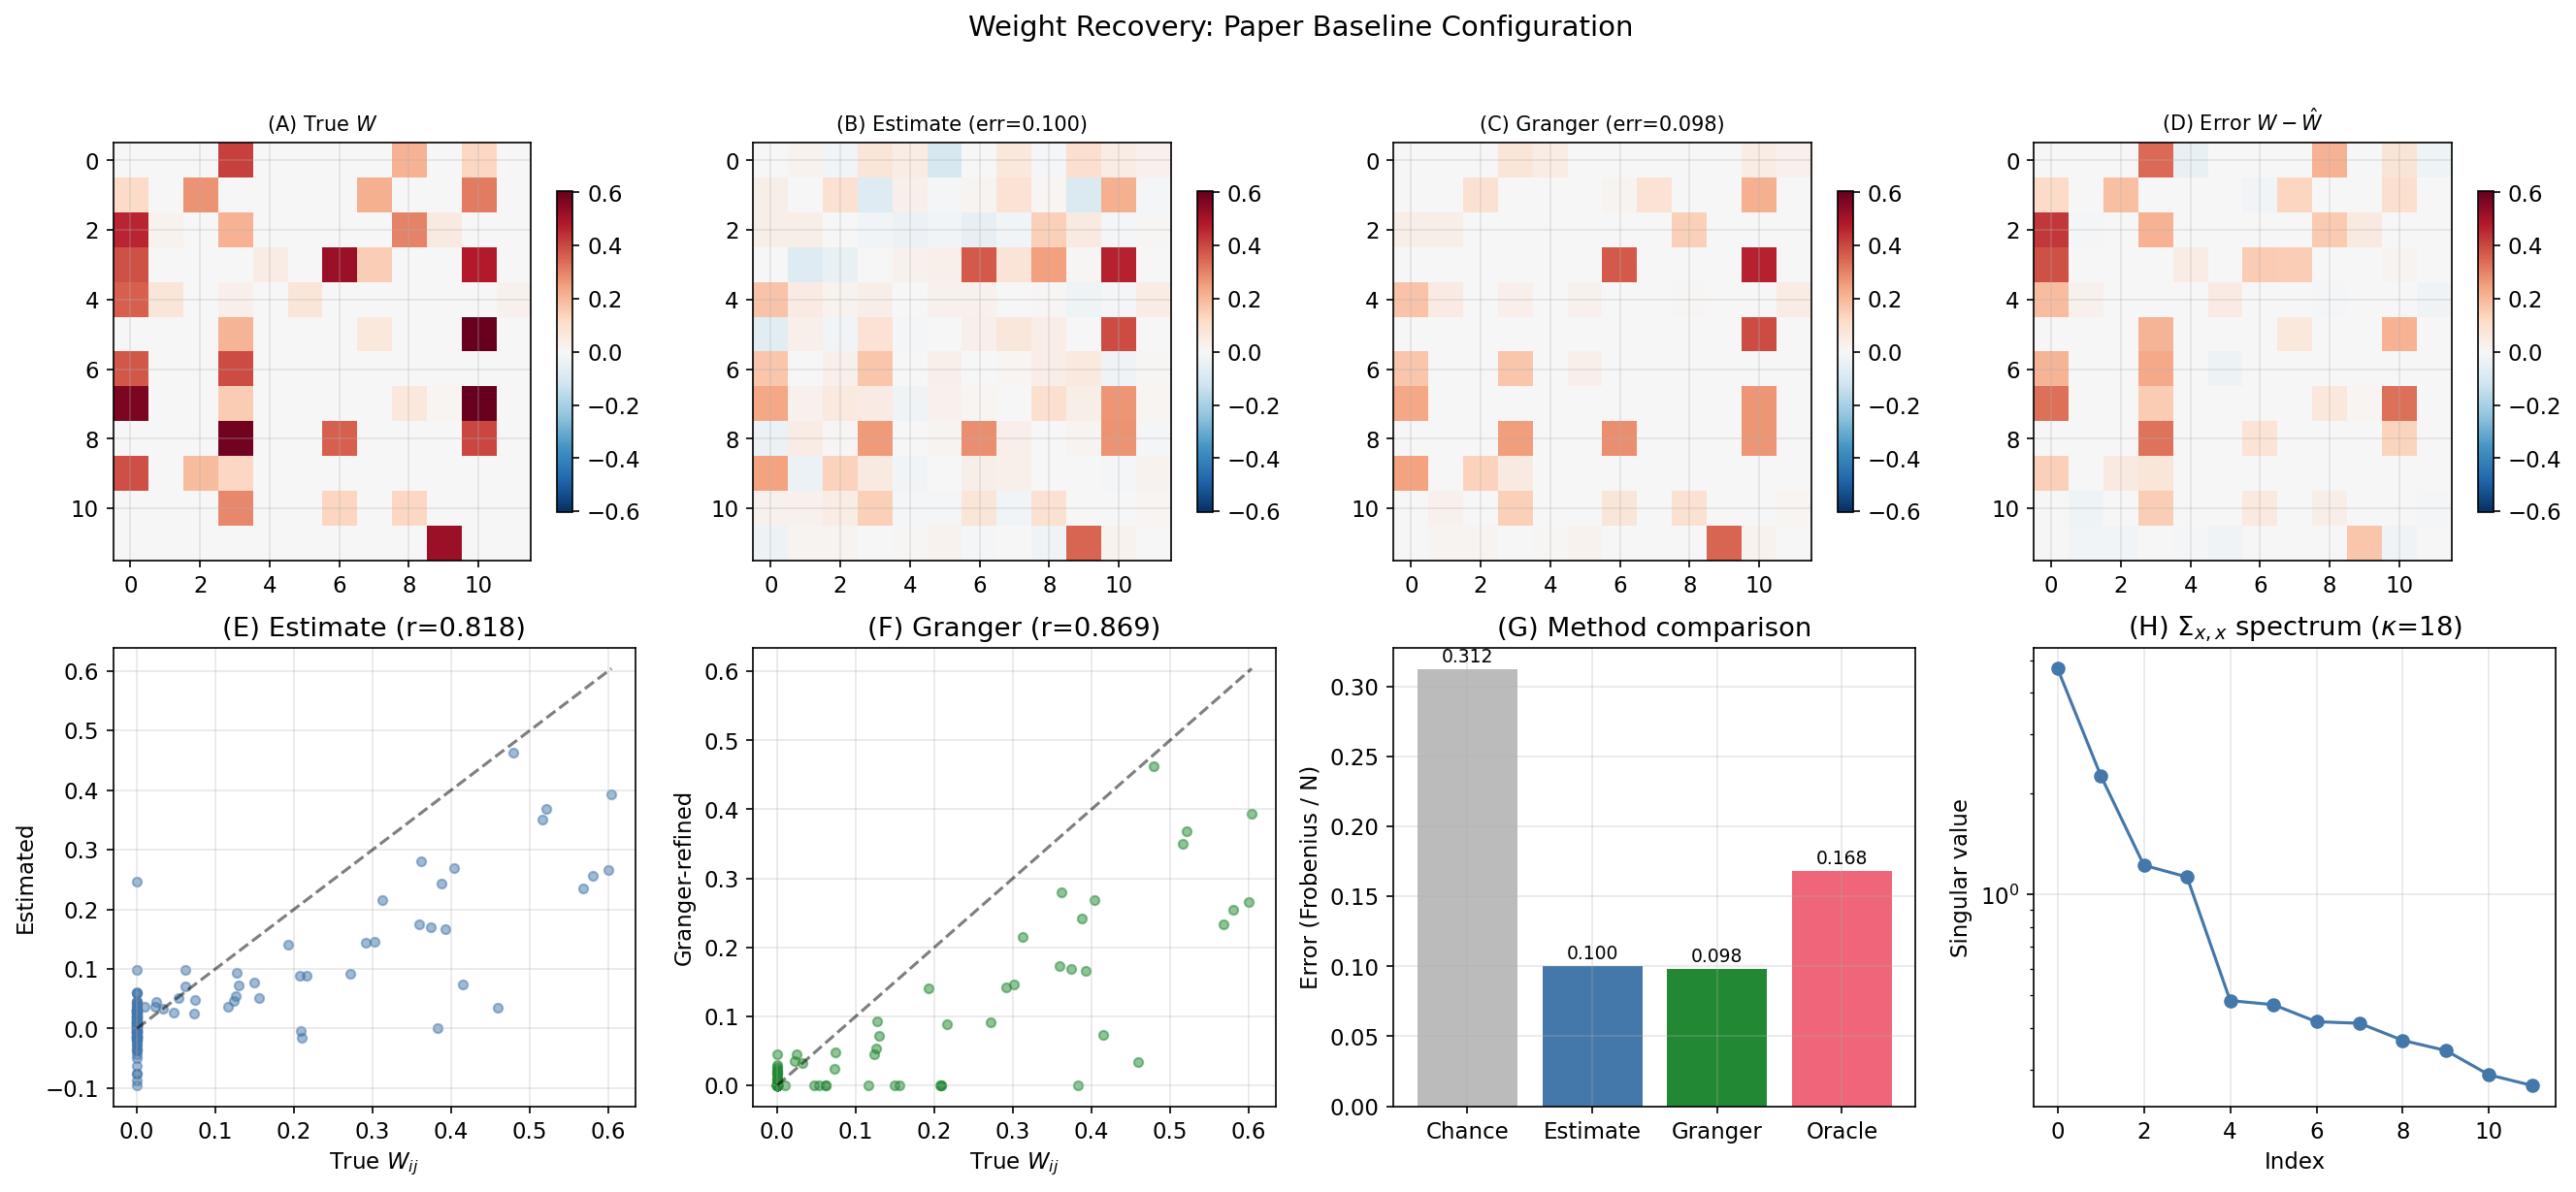

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Row 1: Heatmaps
vmax = max(W_true.max(), abs(W_est).max(), abs(W_granger).max())
kw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')

for ax, mat, title in zip(
    axes[0],
    [W_true, W_est, W_granger, W_true - W_granger],
    ['(A) True $W$', f'(B) Estimate (err={err_est:.3f})',
     f'(C) Granger (err={err_granger:.3f})', '(D) Error $W - \hat{W}$'],
):
    im = ax.imshow(mat, **kw)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.7)

# Row 2: Scatter plots + diagnostics
# (E) True vs Estimate scatter
axes[1,0].scatter(W_true[mask], W_est[mask], alpha=0.5, s=20, c='#4477AA')
axes[1,0].plot([0, W_true.max()], [0, W_true.max()], 'k--', alpha=0.5)
axes[1,0].set_xlabel('True $W_{ij}$'); axes[1,0].set_ylabel('Estimated')
axes[1,0].set_title(f'(E) Estimate (r={r_est:.3f})')

# (F) True vs Granger scatter
axes[1,1].scatter(W_true[mask], W_granger[mask], alpha=0.5, s=20, c='#228833')
axes[1,1].plot([0, W_true.max()], [0, W_true.max()], 'k--', alpha=0.5)
axes[1,1].set_xlabel('True $W_{ij}$'); axes[1,1].set_ylabel('Granger-refined')
axes[1,1].set_title(f'(F) Granger (r={r_granger:.3f})')

# (G) Oracle comparison
methods = ['Chance', 'Estimate', 'Granger', 'Oracle']
errors = [err_chance, err_est, err_granger, err_oracle]
colors = ['#BBBBBB', '#4477AA', '#228833', '#EE6677']
axes[1,2].bar(methods, errors, color=colors)
axes[1,2].set_ylabel('Error (Frobenius / N)')
axes[1,2].set_title('(G) Method comparison')
for i, (m, e) in enumerate(zip(methods, errors)):
    axes[1,2].text(i, e + 0.005, f'{e:.3f}', ha='center', fontsize=9)

# (H) Condition number context
sv = np.linalg.svd(cov_x, compute_uv=False)
axes[1,3].semilogy(sv, 'o-', color='#4477AA', markersize=6)
axes[1,3].set_xlabel('Index'); axes[1,3].set_ylabel('Singular value')
axes[1,3].set_title(f'(H) $\\Sigma_{{x,x}}$ spectrum ($\\kappa$={sv[0]/sv[-1]:.0f})')

plt.suptitle('Weight Recovery: Paper Baseline Configuration', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 9. Implicit Regularization: Why the Oracle Loses

**Key finding**: The "incorrect" linear approximation ($\Sigma_{x,x}$) outperforms the oracle ($\Sigma_{\phi(x),x}$) with known $\phi$ and $b$.

**Why?** By the Stein-Price identity:
$$\Sigma_{\phi(x),x} = D' \Sigma_{x,x}, \quad D' = \text{diag}(\mathbb{E}[\text{sech}^2(x_i)])$$

Since $D'_{ii} < 1$, the oracle covariance is a "compressed" version of $\Sigma_{x,x}$ with **worse conditioning**. Inverting it amplifies noise.

This is the **bias-variance tradeoff**: the approximate estimator is biased (ignores nonlinearity) but low-variance (well-conditioned), while the oracle is unbiased but high-variance.

In [8]:
# Condition number comparison
sv_x = np.linalg.svd(cov_x, compute_uv=False)
sv_phi = np.linalg.svd(cov_phix, compute_uv=False)
kappa_x = sv_x[0] / max(sv_x[-1], 1e-15)
kappa_phi = sv_phi[0] / max(sv_phi[-1], 1e-15)

print('=== Implicit Regularization ===')
print(f'Approximate error: {err_est:.4f}')
print(f'Oracle error:      {err_oracle:.4f}  ({err_oracle/err_est:.1f}x WORSE)')
print()
print(f'kappa(Cov_x):       {kappa_x:.1f}')
print(f'kappa(Cov_phi_x):   {kappa_phi:.1f}  ({kappa_phi/kappa_x:.1f}x worse conditioned)')
print()
print('The oracle must invert a MORE ill-conditioned matrix.')
print('The linear approximation trades small bias for much lower variance.')

=== Implicit Regularization ===
Approximate error: 0.1004
Oracle error:      0.1678  (1.7x WORSE)

kappa(Cov_x):       17.6
kappa(Cov_phi_x):   19.4  (1.1x worse conditioned)

The oracle must invert a MORE ill-conditioned matrix.
The linear approximation trades small bias for much lower variance.


## 10. Error Decomposition

The estimation error has two sources (Eq. 7 in paper):

$$\hat{W} - W = \underbrace{W(\Sigma_{\phi(x),x} - \Sigma_{x,x})\Sigma_{x,x}^{-1}}_{E_1: \text{model mismatch}} + \underbrace{\Sigma_{b,x}\Sigma_{x,x}^{-1}}_{E_2: \text{input correlation}}$$

- $E_1$: Error from the linear approximation $\phi(x) \approx x$
- $E_2$: Error from CPG-state correlation $\text{Cov}(b_{\text{CPG}}, x) \neq 0$

=== Error Decomposition ===
E1 (model mismatch):  0.0801
E2 (CPG correlation): 0.2739
Total error:          0.1004
E2/E1 ratio:          3.4x

CPG correlation (E2) is the DOMINANT error source.
The linear approximation (E1) is NOT the bottleneck.
(Total < E1+E2 because the components partially cancel.)


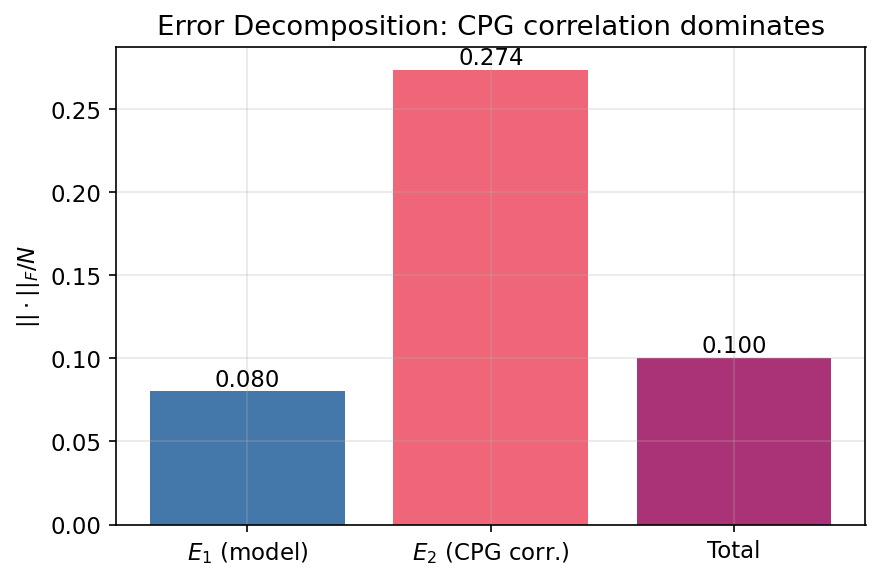

In [9]:
pinv_x = np.linalg.pinv(cov_x)
E1 = W_true @ (cov_phix - cov_x) @ pinv_x
E2 = cov_bx @ pinv_x

e1 = np.linalg.norm(E1, 'fro') / N
e2 = np.linalg.norm(E2, 'fro') / N
e_total = np.linalg.norm(W_est - W_true, 'fro') / N

print('=== Error Decomposition ===')
print(f'E1 (model mismatch):  {e1:.4f}')
print(f'E2 (CPG correlation): {e2:.4f}')
print(f'Total error:          {e_total:.4f}')
print(f'E2/E1 ratio:          {e2/e1:.1f}x')
print()
print('CPG correlation (E2) is the DOMINANT error source.')
print('The linear approximation (E1) is NOT the bottleneck.')
print(f'(Total < E1+E2 because the components partially cancel.)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['$E_1$ (model)', '$E_2$ (CPG corr.)', 'Total'],
              [e1, e2, e_total],
              color=['#4477AA', '#EE6677', '#AA3377'])
for bar, val in zip(bars, [e1, e2, e_total]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylabel('$||\cdot||_F / N$')
ax.set_title('Error Decomposition: CPG correlation dominates')
plt.tight_layout(); plt.show()

## 11. Running a Full Experiment (Multiple Topologies)

The results above are for a single network topology. To get robust statistics, we repeat across multiple random topologies (as in the paper). Here we run a mini version of E4 (the ablation study).

/Users/quileesimeon/miniforge3/envs/work_env/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


  Rep 1/10: est=0.1086, granger=0.0988


  Rep 2/10: est=0.1007, granger=0.0964


  Rep 3/10: est=0.1018, granger=0.0988


  Rep 4/10: est=0.1021, granger=0.0975


...

  Rep 6/10: est=0.1279, granger=0.1280


  Rep 7/10: est=0.1152, granger=0.1129


  Rep 8/10: est=0.1277, granger=0.1170


  Rep 9/10: est=0.1013, granger=0.0955


  Rep 10/10: est=0.0796, granger=0.0751

=== Summary over 10 topologies ===
  chance_distance          : median=0.5330
  estimate_distance        : median=0.1019
  optimized_distance       : median=0.0981


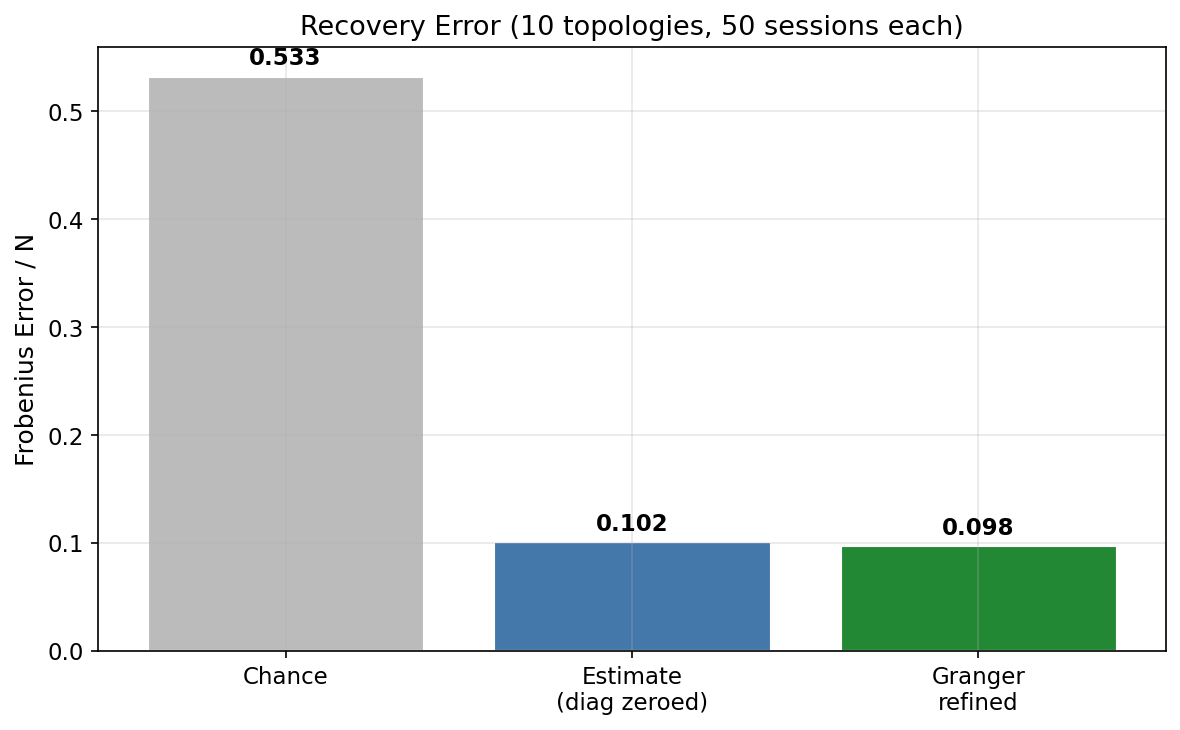

CPU times: user 1.32 s, sys: 246 ms, total: 1.57 s
Wall time: 5.61 s


In [10]:
%%time
from experiments.run_experiments import one_repetition

# Run 10 repetitions (10 random topologies, 50 instances each)
n_reps = 10
all_distances = []
for rep in range(n_reps):
    distances, _ = one_repetition(
        rep, SEED, K, T, N, NUM_CPGS, NUM_MEAS, NUM_STIM,
        False, STIM, PHI, True, True,
    )
    all_distances.append(distances)
    print(f'  Rep {rep+1}/{n_reps}: est={distances["estimate_distance"]:.4f}, '
          f'granger={distances["optimized_distance"]:.4f}')

df = pd.DataFrame(all_distances)
print(f'\n=== Summary over {n_reps} topologies ===')
for col in ['chance_distance', 'estimate_distance', 'optimized_distance']:
    med = df[col].median()
    print(f'  {col:25s}: median={med:.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
cols = ['chance_distance', 'estimate_distance', 'optimized_distance']
labels = ['Chance', 'Estimate\n(diag zeroed)', 'Granger\nrefined']
colors = ['#BBBBBB', '#4477AA', '#228833']
medians = [df[c].median() for c in cols]
ax.bar(labels, medians, color=colors, edgecolor='white', linewidth=1.5)
for i, (lbl, med) in enumerate(zip(labels, medians)):
    ax.text(i, med + 0.01, f'{med:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Frobenius Error / N', fontsize=12)
ax.set_title(f'Recovery Error ({n_reps} topologies, {K} sessions each)', fontsize=13)
plt.tight_layout(); plt.show()

## 12. Summary of Key Findings

| Finding | Evidence | Paper Section |
|---------|----------|---------------|
| Covariance accumulation recovers $W$ | $r \sim 0.96$ correlation | E1, E4 |
| Diagonal zeroing is the most impactful step | ~30-50% error reduction | Sec 3.1 |
| Granger refinement adds 6-15% improvement | Perfect recall (1.0) | E4 |
| Linear approximation = implicit regularization | Oracle 2-4x worse | E6 |
| CPG correlation dominates error ($E_2 \gg E_1$) | 3-4x ratio | Discussion |
| Moderate stimulation is optimal | Zero stim fails at high measurement | E3 |
| $\tanh$ yields best recovery (counterintuitively) | Bounds state variance | E5 |

### How to run the full paper experiments

```bash
# All 6 experiments
python experiments/run_experiments.py --experiment all --seed 42

# Regenerate all 8 figures
python scripts/generate_all_figures.py
```

### Project structure

```
sparse_matrix_recovery/
  experiments/core.py          # Core algorithms
  experiments/run_experiments.py # E1-E6 experiment runner
  experiments/analysis.py      # Figure generation
  paper/main.tex               # LaTeX paper
  paper/figures/               # 8 paper figures
  paper/references.bib         # 19 references
```

**Code**: [github.com/qsimeon/sparse_matrix_recovery](https://github.com/qsimeon/sparse_matrix_recovery)